# Домашнее задание. Классификация изображений
Необходимо классифицировать персонажей Симпсонов по данным скриншотам из сериала.

In [1]:
!python --version

Python 3.10.12


### Установка зависимостей

In [ ]:
import torch
import numpy as np
import os
import PIL
from google.colab import drive
import pickle
from tqdm import tqdm, tqdm_notebook
from PIL import Image
from pathlib import Path
from torchvision import transforms
from multiprocessing.pool import ThreadPool
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
from matplotlib import colors, pyplot as plt
#С этой командой все графики будут отображаться под ячейкой с кодом. Без неё отображаться ничего не будет
%matplotlib inline
import warnings
# в sklearn не все гладко, чтобы в colab удобно выводить картинки
# мы будем игнорировать warnings
warnings.filterwarnings(action='ignore', category=DeprecationWarning)
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties
import pandas as pd
import albumentations as A
from torch.utils.data import WeightedRandomSampler

In [ ]:
drive.mount('/content/drive/')
os.chdir('/content/drive/My Drive/Colab Notebooks/Deep Learning (1 курс)/Занятия 19-20. Продвинутое обучение нейросетей, классификация изображений')
#!unzip -q /content/drive/My\ Drive/Colab\ Notebooks/Deep\ Learning\ \(1\ курс\)/Занятия\ 19-20.\ Продвинутое\ обучение\ нейросетей,\ классификация\ изображений/journey-springfield.zip

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
DATA_MODES = ['train', 'val', 'test'] #Обозначаем виды данных (режим работы сети)
RESCALE_SIZE = 224 #Размер изображения будем менять до 224х224, так как они все разного размера

Напишем свой класс Dataset, в котором определим аугментацию и преобразование изображений.

Аугментация необходима, так как вроде картинок много, но могло бы быть и ещё больше. И вроде как аугментация - это что-то, что делают по умолчанию при обучении нейронных сетей на картинках (а может и не только на картинках). Кроме того, в дальнейшем мы увидим, что данные не сбалансированы, а значит аугменатция поможет нам получить много картинок для баланса.

Преобразование картинок происходит как-то странно, я его ещё не понял, просто копирую текст из бейзлайна:

*Ниже мы исспользуем враппер над датасетом для удобной работы. Вам стоит понимать, что происходит с LabelEncoder и  с torch.Transformation.*

*ToTensor конвертирует  PIL Image с параметрами в диапазоне [0, 255] (как все пиксели) в FloatTensor размера (C x H x W) [0,1] , затем производится масштабирование:
$input = \frac{input - \mu}{\text{standard deviation}} $, <br>       константы - средние и дисперсии по каналам на основе ImageNet*


*Стоит также отметить, что мы переопределяем метод __getitem__ для удобства работы с данной структурой данных.
 Также используется LabelEncoder для преобразования строковых меток классов в id и обратно. В описании датасета указано, что картинки разного размера, так как брались напрямую с видео, поэтому следуем привести их к одному размер (это делает метод  _prepare_sample)*

In [ ]:
class SimpsonsDataset(Dataset):
    def __init__(self, files, mode):
        super().__init__()
        self.files = files #список файлов для загрузки
        self.mode = mode #режим работы (train, val, test)
        if self.mode not in DATA_MODES:
            print(f"{self.mode} is not correct; correct modes: {DATA_MODES}")
            raise NameError
        self.len_ = len(self.files)
        #LabelEncoder преобразует категориальные признаки в числа от 0 до n-1 для n категорий. Например, ['Amsterdam', 'Paris', 'Rome'] -> [0, 1, 2].
        #Он используется только для таргетов, так как для признаков объекта нельзя сказать, что Paris > Amsterdam, а для таргетов мы не сравниваем категории.
        self.label_encoder = LabelEncoder()
        if self.mode != 'test':
            #path.parent.name - путь, где лежат self.files, у него смотрят верхнюю папку parent и её название, так как все картинки разложены по папкам с
            #названиями типа Bart Simpson, а сами картинки просто пронумерованы типа pic_001. Здесь мы получаем список категорий таргета
            self.labels = [path.parent.name for path in self.files]
            self.label_encoder.fit(self.labels) #А здесь переводим названия категорий в числа от 0 до n-1
            #Здесь используется pickle, который нужен для сериализации данных. Здесь создается файл label_encoder.pkl в режиме двоичной записи, и туда пишутся категории 0 n-1. Зачем? Пока хз
            with open('label_encoder.pkl', 'wb') as le_dump_file:
                pickle.dump(self.label_encoder, le_dump_file)

    def __len__(self):
        return self.len_

    def load_sample(self, file):
        image = Image.open(file)
        image.load()
        return image

    def __getitem__(self, index):
        aug_p = 0.5 if self.mode != 'test' else 0
        augmentation = A.Compose([
            A.Rotate(limit=25, p=aug_p),
            A.HorizontalFlip(p=aug_p),
            A.RandomBrightnessContrast(p=aug_p),
            A.HueSaturationValue(p=aug_p),
            A.Resize(RESCALE_SIZE, RESCALE_SIZE),
        ])
        transform = transforms.Compose([
            transforms.Lambda(lambda x: np.array(x, dtype='float32') / 255),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) #как я и писал выше, здесь что-то непонятное происходит
        ])
        x = self.load_sample(self.files[index])
        x = augmentation(image=np.array(x))['image']
        x = transform(x)
        if self.mode == 'test':
            return x
        else:
            label = self.labels[index] #Надо дать объекту его класс (лейбл). Для этого нам в функцию передали индекс метки, и мы по нему из списка меток получаем метку
            label_id = self.label_encoder.transform([label]) #Получаем числовое представление метки (метод transform(['Paris']) = [1] из примера выше)
            y = label_id.item() #item() просто позвращает занчение тензора, если оно там одно
            return x, y #Возвращаем тензор преобразованного изображения и его метку

Теперь посмотрим на распределение данных, и, если понадобится, будем брать выборки сбалансированно во время обучения.

In [ ]:
TRAIN_DIR = Path('./train/')
TEST_DIR = Path('./testset')
train_val_files = sorted(list(TRAIN_DIR.rglob('*.jpg')))
test_files = sorted(list(TEST_DIR.rglob('*.jpg')))
train_val_labels = [path.parent.name for path in train_val_files]
train_files, val_files = train_test_split(train_val_files, test_size=0.25, stratify=train_val_labels)
train_labels = [path.parent.name for path in train_files]
train_dataset = SimpsonsDataset(train_files, 'train')
val_dataset = SimpsonsDataset(val_files, 'val')
test_dataset = SimpsonsDataset(test_files, 'test')

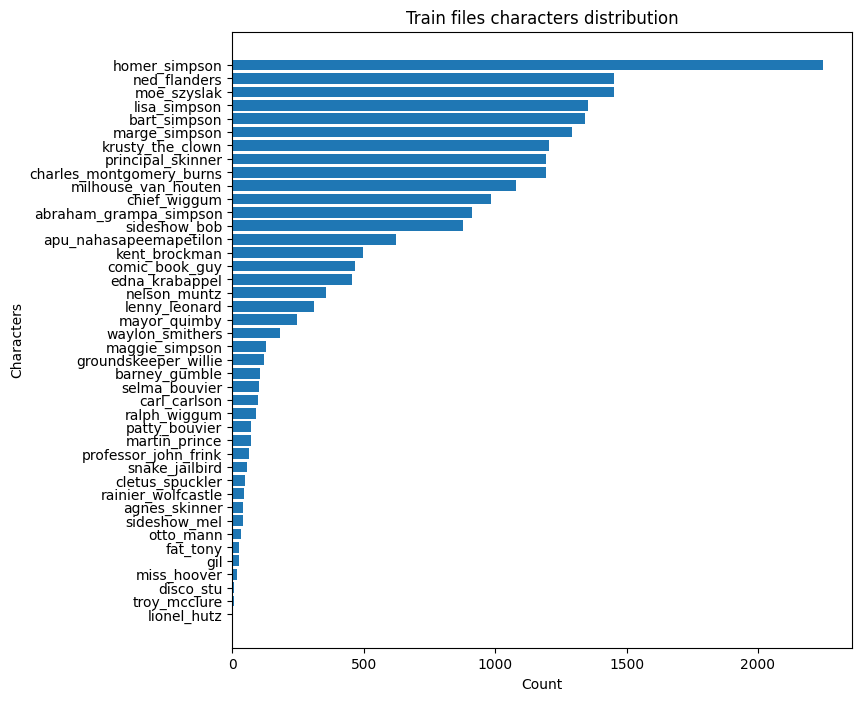

In [ ]:
counts = pd.Series(train_val_labels).value_counts()
plt.figure(figsize=(8,8))
plt.barh(counts.keys()[::-1], counts.sort_values(ascending=True))
plt.title('Train files characters distribution')
plt.xlabel('Count')
plt.ylabel('Characters')
plt.show()

Как видим, данные не сбалансированы. Зададим каждому объекту с меткой (таргетом) Y вес, обратно пропорциональный количеству объектов с такой же меткой Y. То есть, чем реже встречается некоторая метка в выборке, тем больший вес будут иметь объекты с такой меткой. С помощью **WeightedRandomSampler** dataloader будет чаще выбирать объекты с бóльшим весом.

In [ ]:
label_weights = {k: 1 / v for k, v in counts.items()}
sample_weights = [label_weights[label] for label in train_dataset.labels]
train_sampler = WeightedRandomSampler(sample_weights, num_samples=int(counts.max() * len(label_weights)), replacement=True)

### Построение нейросети
Опишем нейросеть и все функции для её обучения.

In [ ]:
class BasicBlock(nn.Module):
    def __init__(self, ins, outs, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(ins, outs, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(outs)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(outs, outs, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(outs)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

class MyResNet34(nn.Module):
    def __init__(self, n_classes, ins, block, layers):
        super().__init__()
        self.ins = ins
        self.conv1 = nn.Conv2d(3, self.ins, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.ins)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 16, layers[0])
        self.layer2 = self._make_layer(block, 32, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 64, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, n_classes)

    def _make_layer(self, block, outs, blocks, stride=1):
        downsample = None
        if stride != 1 or self.ins != outs:
            downsample = nn.Sequential(
                nn.Conv2d(self.ins, outs, 1, stride, bias=False),
                nn.BatchNorm2d(outs),
            )
        layers = []
        layers.append(block(self.ins, outs, stride, downsample))
        self.ins = outs
        for _ in range(1, blocks):
            layers.append(block(self.ins, outs))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)           # 224x224
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)         # 112x112
        x = self.layer1(x)          # 56x56
        x = self.layer2(x)          # 28x28
        x = self.layer3(x)          # 14x14
        x = self.layer4(x)          # 7x7
        x = self.avgpool(x)         # 1x1
        x = torch.flatten(x, 1)     # remove 1 X 1 grid and make vector of tensor shape
        x = self.fc(x)
        return x

In [ ]:
class SimpleBasicBlock(nn.Module):
    def __init__(self, ins, outs, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(ins, outs, kernel_size=3, stride=stride, padding=1, bias=False)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=2)
        self.conv2 = nn.Conv2d(outs, outs, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(outs)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.relu(out)
        out = self.maxpool(out)
        out = self.conv2(out)
        out = self.bn1(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        return out

class MyCNN(nn.Module):
    def __init__(self, n_classes, ins, block, layers):
        super().__init__()
        self.ins = ins
        self.conv1 = nn.Conv2d(3, self.ins, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(self.ins)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 32, layers[0])
        self.layer2 = self._make_layer(block, 64, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 128, layers[2], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc1 = nn.Linear(128, 256)
        self.fc2 = nn.Linear(256, 512)
        self.fc3 = nn.Linear(512, n_classes)

    def _make_layer(self, block, outs, blocks, stride=1):
        downsample = None
        if stride != 1 or self.ins != outs:
            downsample = nn.Sequential(
                nn.Conv2d(self.ins, outs, 1, stride, bias=False),
                nn.BatchNorm2d(outs),
            )
        layers = []
        layers.append(block(self.ins, outs, stride, downsample))
        self.ins = outs
        for _ in range(1, blocks):
            layers.append(block(self.ins, outs))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)         # 1x1
        x = torch.flatten(x, 1)     # remove 1 X 1 grid and make vector of tensor shape
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        return x

In [ ]:
class SimpleCnn(nn.Module):

    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(8)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(16)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(32)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(64)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.BatchNorm2d(96)
        )

        self.out = nn.Linear(96 * 5 * 5, n_classes)


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = x.view(x.size(0), -1)
        logits = self.out(x)
        return logits

In [ ]:
def fit_epoch(model, train_loader, criterion, optimizer, scheduler):
    running_loss = 0.0
    running_corrects = 0
    processed_data = 0
    for inputs, labels in train_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        preds = torch.argmax(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        processed_data += inputs.size(0)
    scheduler.step()
    train_loss = running_loss / processed_data
    train_acc = running_corrects.cpu().numpy() / processed_data
    return train_loss, train_acc

In [ ]:
def eval_epoch(model, val_loader, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    processed_size = 0
    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.set_grad_enabled(False):
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            preds = torch.argmax(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        processed_size += inputs.size(0)
    val_loss = running_loss / processed_size
    val_acc = running_corrects.double() / processed_size
    return val_loss, val_acc

In [ ]:
def train(train_loader, val_loader, model, epochs):
    history = []
    log_template = "\nEpoch {ep:03d} train_loss: {t_loss:0.4f} \
    val_loss {v_loss:0.4f} train_acc {t_acc:0.4f} val_acc {v_acc:0.4f}"

    #tqdm - это библиотека для отображения прогресс-бара. Показывает сколько процентов выполнено и сколько времени прошло на каждом шагу
    with tqdm(desc="epoch", total=epochs) as pbar_outer:
        opt = torch.optim.Adam(model.parameters(), lr=1e-3)
        criterion = nn.CrossEntropyLoss()
        scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=3, gamma=0.1)

        for epoch in range(epochs):
            train_loss, train_acc = fit_epoch(model, train_loader, criterion, opt, scheduler)
            print("loss", train_loss)

            val_loss, val_acc = eval_epoch(model, val_loader, criterion)
            history.append((train_loss, train_acc, val_loss, val_acc))

            pbar_outer.update(1)
            tqdm.write(log_template.format(ep=epoch+1, t_loss=train_loss,\
                                           v_loss=val_loss, t_acc=train_acc, v_acc=val_acc))
            if (epoch > 0) and (epoch % 3 == 0):
                torch.save(model.state_dict(), 'simple_cnn_weights' + str(epoch) + '.pth')

    return history

In [ ]:
def predict(model, test_loader):
    with torch.no_grad():
        logits = []

        for inputs in test_loader:
            inputs = inputs.to(DEVICE)
            model.eval()
            outputs = model(inputs).cpu()
            logits.append(outputs)

    probs = nn.functional.softmax(torch.cat(logits), dim=-1).numpy()
    return probs

Осталось натренировать сеть и посмотреть результат.

In [ ]:
train_on_gpu = torch.cuda.is_available()
if torch.cuda.is_available():
    print('CUDA is available!  Training on GPU ...')
    DEVICE = torch.device('cuda')
else:
    print('CUDA is not available.  Training on CPU ...')
    DEVICE = torch.device('cpu')

n_classes = len(np.unique(train_val_labels))
#layers = [1, 2, 2, 2]
#model = MyResNet34(n_classes, 8, BasicBlock, layers).to(DEVICE)
#layers = [1, 1, 1]
#model = MyCNN(n_classes, 16, SimpleBasicBlock, layers).to(DEVICE)
model = SimpleCnn(n_classes).to(DEVICE)
print("we will classify: {}".format(n_classes))
print(model)

CUDA is available!  Training on GPU ...
we will classify :42
SimpleCnn(
  (conv1): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv2): Sequential(
    (0): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv4): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): 

In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=128, sampler=train_sampler, num_workers=4)
val_dataloader = DataLoader(val_dataset, batch_size=128, shuffle=False)
history = train(train_dataloader, val_dataloader, model, 9)

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(
epoch:   0%|          | 0/9 [00:00<?, ?it/s]

loss 0.9802005791115164


epoch:  11%|█         | 1/9 [12:40<1:41:26, 760.86s/it]


Epoch 001 train_loss: 0.9802     val_loss 1.1752 train_acc 0.7466 val_acc 0.6916


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


...

/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


loss 0.1089546136851555


epoch:  67%|██████▋   | 6/9 [1:10:41<34:52, 697.39s/it]


Epoch 006 train_loss: 0.1090     val_loss 0.7362 train_acc 0.9690 val_acc 0.8319


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [ ]:
torch.save(model.state_dict(), 'simple_cnn_weights.pth')

Посмотрим кривые обучения.

In [ ]:
loss, acc, val_loss, val_acc = zip(*history)
plt.figure(figsize=(15, 9))
plt.plot(loss, label="train_loss")
plt.plot(val_loss, label="val_loss")
plt.legend(loc='best')
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

И посмотрим оценку по f1.

In [ ]:
idxs = list(map(int, np.random.uniform(0,1000, 20)))
imgs = [val_dataset[id][0].unsqueeze(0) for id in idxs]
probs_ims = predict(model, imgs)
y_pred = np.argmax(probs_ims,-1)
actual_labels = [val_dataset[id][1] for id in idxs]
f1 = f1_score(actual_labels, y_pred, average='micro')
print("F1-оценка:", f1)

### Вычисление результатов для тестовой выборки и отправка на kuggle

In [ ]:
test_dataloader = DataLoader(test_dataset, shuffle=False, batch_size=128)
predictions = predict(model, test_dataloader)
label_encoder = pickle.load(open("label_encoder.pkl", 'rb'))
predictions = label_encoder.inverse_transform(np.argmax(predictions, axis=1))
test_filenames = [path.name for path in test_dataset.files]

In [ ]:
my_submit = pd.DataFrame({'Id': test_filenames, 'Expected': predictions})
my_submit.to_csv('my_submit.csv', index=False)
my_submit.head()